# 04 — Modeling

Goal: compare full vs. selected feature sets, compare class-imbalance handling strategies, tune the most promising combinations with Bayesian optimization, and find the minimal feature count that preserves performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import joblib
import optuna
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

REPORT_DIR = '../reports/04_modeling'
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)

## 1. Load Data

Both feature-set variants share identical train/test row membership (same `random_state` in `03_preprocessing.ipynb`), so PR-AUC is directly comparable between them.

In [2]:
datasets = {}
for name in ['full', 'selected']:
    train = pd.read_csv(f'../data/processed/train_{name}.csv')
    test = pd.read_csv(f'../data/processed/test_{name}.csv')
    X_train = train.drop(columns=['Class'])
    y_train = train['Class']
    X_test = test.drop(columns=['Class'])
    y_test = test['Class']
    datasets[name] = (X_train, y_train, X_test, y_test)
    print(f'[{name}] train: {X_train.shape}, test: {X_test.shape}, features: {list(X_train.columns)}')

[full] train: (227845, 30), test: (56962, 30), features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled']


[selected] train: (227845, 28), test: (56962, 28), features: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1', 'V9', 'V5', 'V2', 'V6', 'V21', 'V19', 'V20', 'V8', 'V27', 'V28', 'V24', 'V13', 'V26', 'V15', 'V25', 'V23', 'V22']


## 2. Define Imbalance Strategies, Models, and Pipeline Builder

- **Imbalance strategies**: `smote`, `random_over` (random oversampling), `random_under` (random undersampling), `class_weight` (no resampling; weighted loss instead).
- Resamplers are wrapped inside an `imblearn` `Pipeline` so they only ever touch the training fold during cross-validation — never the validation fold — avoiding leakage.
- XGBoost has no `class_weight` parameter; for the `class_weight` strategy it uses `scale_pos_weight = negative_count / positive_count` instead.

In [3]:
IMBALANCE_STRATEGIES = ['smote', 'random_over', 'random_under', 'class_weight']
MODEL_NAMES = ['logistic_regression', 'random_forest', 'xgboost']


def make_sampler(strategy):
    if strategy == 'smote':
        return SMOTE(random_state=42)
    if strategy == 'random_over':
        return RandomOverSampler(random_state=42)
    if strategy == 'random_under':
        return RandomUnderSampler(random_state=42)
    if strategy == 'class_weight':
        return None
    raise ValueError(strategy)


def make_model(model_name, strategy, y_train, **hyperparams):
    if model_name == 'logistic_regression':
        kwargs = dict(max_iter=1000, random_state=42)
        if strategy == 'class_weight':
            kwargs['class_weight'] = 'balanced'
        kwargs.update(hyperparams)
        return LogisticRegression(**kwargs)
    if model_name == 'random_forest':
        kwargs = dict(random_state=42, n_jobs=-1)
        if strategy == 'class_weight':
            kwargs['class_weight'] = 'balanced'
        kwargs.update(hyperparams)
        return RandomForestClassifier(**kwargs)
    if model_name == 'xgboost':
        kwargs = dict(random_state=42, eval_metric='aucpr', verbosity=0)
        if strategy == 'class_weight':
            neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
            kwargs['scale_pos_weight'] = neg / pos
        kwargs.update(hyperparams)
        return XGBClassifier(**kwargs)
    raise ValueError(model_name)


def make_pipeline(model_name, strategy, y_train, **hyperparams):
    sampler = make_sampler(strategy)
    model = make_model(model_name, strategy, y_train, **hyperparams)
    steps = []
    if sampler is not None:
        steps.append(('sampler', sampler))
    steps.append(('clf', model))
    return ImbPipeline(steps)


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

## 3. Stage 1 — Coarse Screening (Default Hyperparameters)

All `2 feature sets × 4 imbalance strategies × 3 models = 24` combinations, scored by 3-fold cross-validated PR-AUC with default hyperparameters. This identifies promising candidates cheaply before spending time on Bayesian tuning.

In [4]:
screening_rows = []
for feature_set in ['full', 'selected']:
    X_train, y_train, _, _ = datasets[feature_set]
    for strategy in IMBALANCE_STRATEGIES:
        for model_name in MODEL_NAMES:
            pipe = make_pipeline(model_name, strategy, y_train)
            scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=1)
            screening_rows.append({
                'feature_set': feature_set,
                'imbalance_strategy': strategy,
                'model': model_name,
                'mean_prauc': scores.mean(),
                'std_prauc': scores.std(),
            })
            print(f'[{feature_set}/{strategy}/{model_name}] PR-AUC = {scores.mean():.4f} ± {scores.std():.4f}')

screening_results = pd.DataFrame(screening_rows).sort_values('mean_prauc', ascending=False).reset_index(drop=True)
screening_results.to_csv(f'{REPORT_DIR}/coarse_screening_results.csv', index=False)
screening_results.head(10)

[full/smote/logistic_regression] PR-AUC = 0.7485 ± 0.0240


[full/smote/random_forest] PR-AUC = 0.8380 ± 0.0185


[full/smote/xgboost] PR-AUC = 0.8461 ± 0.0234


[full/random_over/logistic_regression] PR-AUC = 0.7513 ± 0.0264


[full/random_over/random_forest] PR-AUC = 0.8361 ± 0.0145


...

[selected/random_under/xgboost] PR-AUC = 0.7172 ± 0.0434


[selected/class_weight/logistic_regression] PR-AUC = 0.7525 ± 0.0269


[selected/class_weight/random_forest] PR-AUC = 0.8364 ± 0.0132


[selected/class_weight/xgboost] PR-AUC = 0.8502 ± 0.0114


,feature_set,imbalance_strategy,model,mean_prauc,std_prauc
0,selected,class_weight,xgboost,0.850195,0.011403
1,full,random_over,xgboost,0.847197,0.014838
2,full,smote,xgboost,0.846093,0.023362
3,selected,random_over,xgboost,0.844745,0.015463
4,full,class_weight,xgboost,0.842971,0.018870
5,selected,smote,xgboost,0.841360,0.024298
6,full,smote,random_forest,0.838026,0.018536
7,full,class_weight,random_forest,0.836729,0.016772
8,selected,class_weight,random_forest,0.836393,0.013237
9,full,random_over,random_forest,0.836149,0.014532


## 4. Stage 2 — Bayesian Hyperparameter Tuning (Optuna)

Full tuning only on the top 3 candidates from Stage 1 — running this on all 24 combos would take hours once SMOTE/oversampling inflates the training fold to ~450k rows.

> If this runs too slowly on your machine, reduce `N_TRIALS` and/or the number of CV folds below.

In [5]:
TOP_N = 3
N_TRIALS = 30
top_combos = screening_results.head(TOP_N).to_dict('records')


def build_objective(strategy, model_name, X_train, y_train):
    def objective(trial):
        if model_name == 'logistic_regression':
            params = {
                'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
                'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
                'solver': 'liblinear',
            }
        elif model_name == 'random_forest':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 3, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            }
        elif model_name == 'xgboost':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 2, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            }
        else:
            raise ValueError(model_name)

        pipe = make_pipeline(model_name, strategy, y_train, **params)
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=1)
        return scores.mean()
    return objective


tuning_rows = []
tuned_params = {}

for combo in top_combos:
    feature_set, strategy, model_name = combo['feature_set'], combo['imbalance_strategy'], combo['model']
    X_train, y_train, _, _ = datasets[feature_set]

    study = optuna.create_study(direction='maximize')
    study.optimize(build_objective(strategy, model_name, X_train, y_train), n_trials=N_TRIALS)

    tuning_rows.append({
        'feature_set': feature_set,
        'imbalance_strategy': strategy,
        'model': model_name,
        'best_cv_prauc': study.best_value,
        'best_params': json.dumps(study.best_params),
    })
    tuned_params[(feature_set, strategy, model_name)] = study.best_params

    print(f'[{feature_set}/{strategy}/{model_name}] best CV PR-AUC = {study.best_value:.4f}, params = {study.best_params}')

tuning_results = pd.DataFrame(tuning_rows).sort_values('best_cv_prauc', ascending=False).reset_index(drop=True)
tuning_results.to_csv(f'{REPORT_DIR}/bayesian_tuning_results.csv', index=False)
tuning_results

[selected/class_weight/xgboost] best CV PR-AUC = 0.8513, params = {'n_estimators': 255, 'max_depth': 9, 'learning_rate': 0.07861477820544398, 'subsample': 0.9965479283739146, 'colsample_bytree': 0.5729786593970411}


[full/random_over/xgboost] best CV PR-AUC = 0.8556, params = {'n_estimators': 203, 'max_depth': 6, 'learning_rate': 0.15153047541856113, 'subsample': 0.9129704722857716, 'colsample_bytree': 0.8839199210155646}


[full/smote/xgboost] best CV PR-AUC = 0.8480, params = {'n_estimators': 167, 'max_depth': 6, 'learning_rate': 0.17760963699722712, 'subsample': 0.5063043842363855, 'colsample_bytree': 0.8453251842043952}


,feature_set,imbalance_strategy,model,best_cv_prauc,best_params
0,full,random_over,xgboost,0.855597,"{""n_estimators"": 203, ""max_depth"": 6, ""learnin..."
1,selected,class_weight,xgboost,0.851340,"{""n_estimators"": 255, ""max_depth"": 9, ""learnin..."
2,full,smote,xgboost,0.847954,"{""n_estimators"": 167, ""max_depth"": 6, ""learnin..."


## 5. Final Model Selection

In [6]:
best_row = tuning_results.iloc[0]
best_feature_set = best_row['feature_set']
best_strategy = best_row['imbalance_strategy']
best_model_name = best_row['model']
best_params = tuned_params[(best_feature_set, best_strategy, best_model_name)]

X_train, y_train, X_test, y_test = datasets[best_feature_set]

best_pipeline = make_pipeline(best_model_name, best_strategy, y_train, **best_params)
best_pipeline.fit(X_train, y_train)

y_prob = best_pipeline.predict_proba(X_test)[:, 1]
test_prauc = average_precision_score(y_test, y_prob)

print(f'Best combo: feature_set={best_feature_set}, strategy={best_strategy}, model={best_model_name}')
print(f'Test PR-AUC: {test_prauc:.4f}')

print('\nFull vs. selected comparison (tuned candidates):')
print(tuning_results[['feature_set', 'imbalance_strategy', 'model', 'best_cv_prauc']].to_string(index=False))

Best combo: feature_set=full, strategy=random_over, model=xgboost
Test PR-AUC: 0.8844

Full vs. selected comparison (tuned candidates):
feature_set imbalance_strategy   model  best_cv_prauc
       full        random_over xgboost       0.855597
   selected       class_weight xgboost       0.851340
       full              smote xgboost       0.847954


In [7]:
joblib.dump(best_pipeline, '../models/best_model.pkl')

metadata = {
    'feature_set': best_feature_set,
    'imbalance_strategy': best_strategy,
    'model': best_model_name,
    'hyperparameters': best_params,
    'features': list(X_train.columns),
    'test_prauc': test_prauc,
}
with open('../models/best_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: models/best_model.pkl')
print('Saved: models/best_model_metadata.json')

Saved: models/best_model.pkl
Saved: models/best_model_metadata.json


## 6. Feature Count vs. Performance

Using the winning model/strategy/hyperparameters, rank features by importance and retrain on the top `K` for increasing `K` to find the smallest feature count that preserves performance.

K=5: PR-AUC = 0.8112 ± 0.0178


K=10: PR-AUC = 0.8238 ± 0.0227


K=15: PR-AUC = 0.8396 ± 0.0217


K=20: PR-AUC = 0.8489 ± 0.0176


K=25: PR-AUC = 0.8523 ± 0.0135


K=30: PR-AUC = 0.8533 ± 0.0142

Minimal recommended feature count: K=20 (PR-AUC=0.8489, within 1% of max 0.8533)


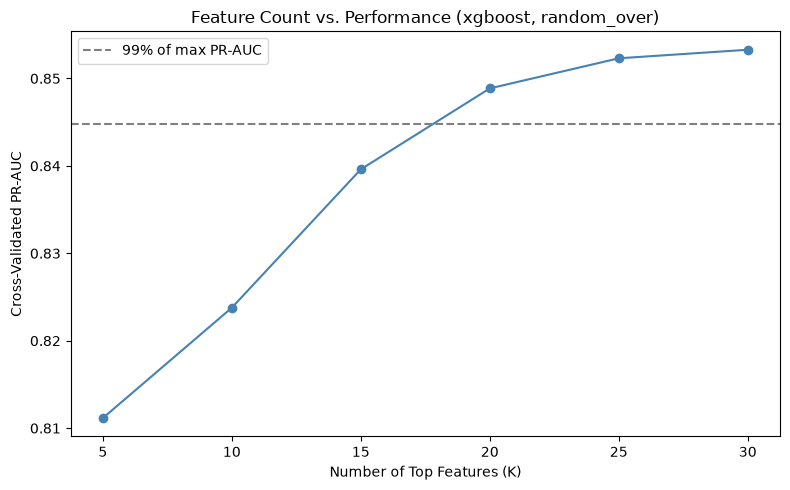

In [8]:
fitted_clf = best_pipeline.named_steps['clf']

if hasattr(fitted_clf, 'feature_importances_'):
    importances = pd.Series(fitted_clf.feature_importances_, index=X_train.columns)
elif hasattr(fitted_clf, 'coef_'):
    importances = pd.Series(np.abs(fitted_clf.coef_[0]), index=X_train.columns)
else:
    raise ValueError('Best model has neither feature_importances_ nor coef_')

ranked_features = importances.sort_values(ascending=False).index.tolist()

k_values = [k for k in [5, 10, 15, 20, 25, 30] if k <= len(ranked_features)]
if len(ranked_features) not in k_values:
    k_values.append(len(ranked_features))

curve_rows = []
for k in k_values:
    top_k_features = ranked_features[:k]
    pipe = make_pipeline(best_model_name, best_strategy, y_train, **best_params)
    scores = cross_val_score(pipe, X_train[top_k_features], y_train, cv=cv, scoring='average_precision', n_jobs=1)
    curve_rows.append({'k': k, 'mean_prauc': scores.mean(), 'std_prauc': scores.std()})
    print(f'K={k}: PR-AUC = {scores.mean():.4f} ± {scores.std():.4f}')

curve_df = pd.DataFrame(curve_rows)
curve_df.to_csv(f'{REPORT_DIR}/feature_count_vs_prauc.csv', index=False)

max_prauc = curve_df['mean_prauc'].max()
minimal_k_row = curve_df[curve_df['mean_prauc'] >= max_prauc * 0.99].iloc[0]
print(f"\nMinimal recommended feature count: K={int(minimal_k_row['k'])} "
      f"(PR-AUC={minimal_k_row['mean_prauc']:.4f}, within 1% of max {max_prauc:.4f})")

plt.figure(figsize=(8, 5))
plt.plot(curve_df['k'], curve_df['mean_prauc'], marker='o', color='steelblue')
plt.axhline(max_prauc * 0.99, linestyle='--', color='gray', label='99% of max PR-AUC')
plt.xlabel('Number of Top Features (K)')
plt.ylabel('Cross-Validated PR-AUC')
plt.title(f'Feature Count vs. Performance ({best_model_name}, {best_strategy})')
plt.legend()
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/feature_count_vs_prauc.png', dpi=150)
plt.show()